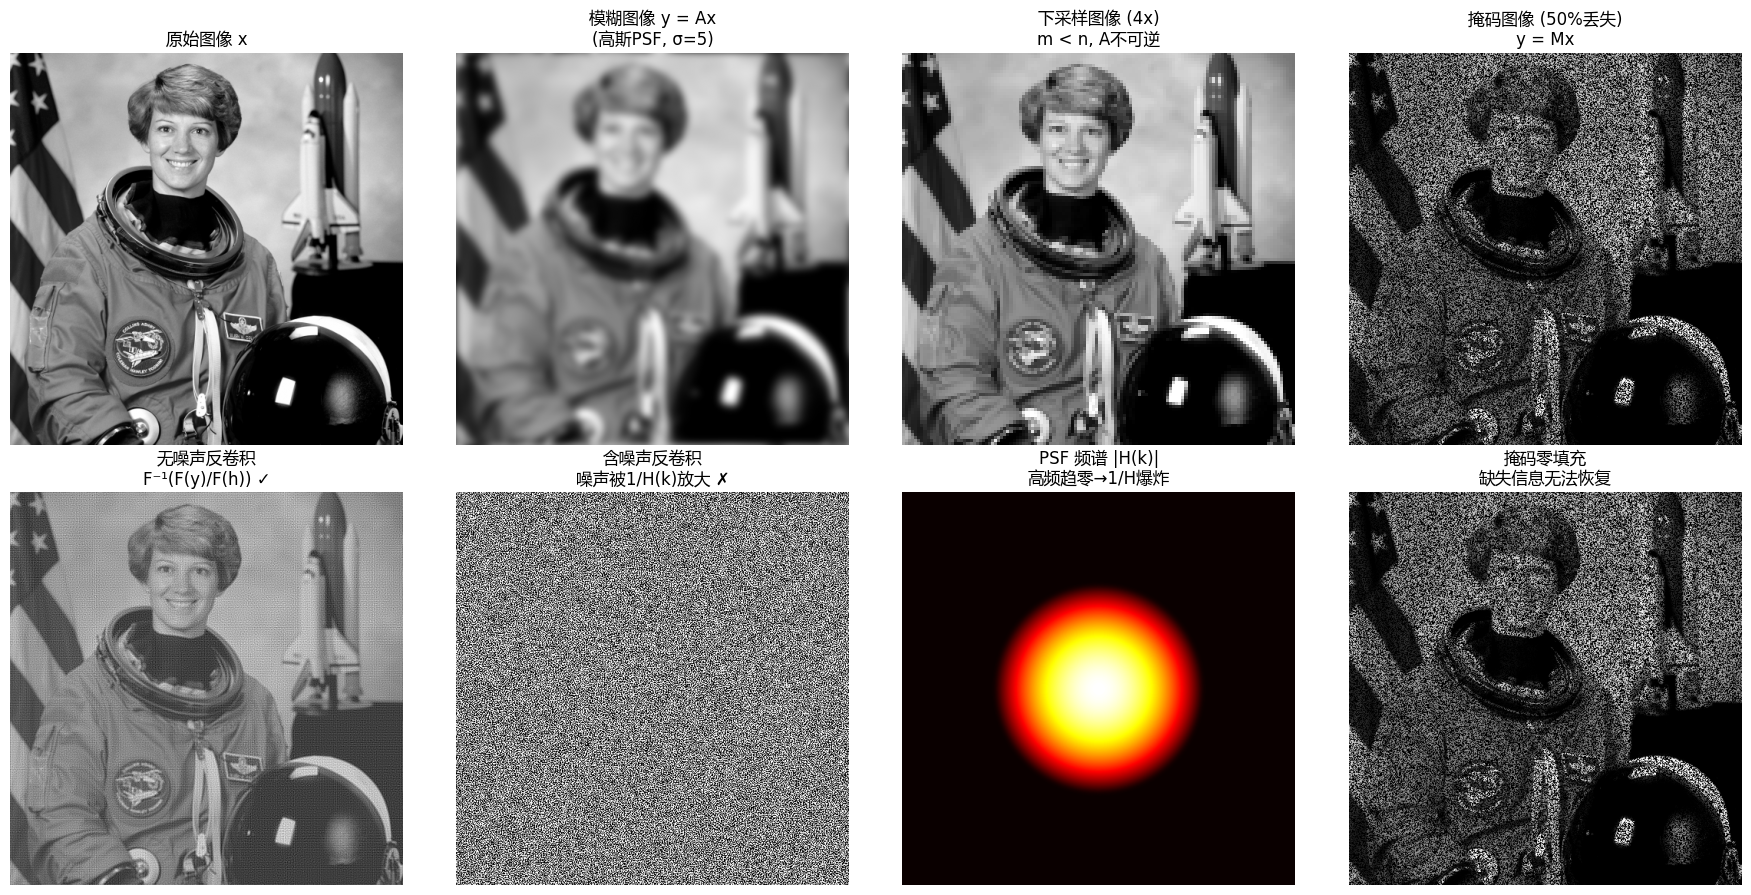

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import astronaut
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================
np.random.seed(42)

# ---- 1. 加载图像 ----
x_color = astronaut()
x = rgb2gray(x_color)
n = x.shape[0]

# ---- 2. 构建高斯 PSF 和模糊算子 ----
def gaussian_psf(size, sigma):
    """生成频域中心的高斯 PSF"""
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    h = h / h.sum()
    return h

def blur_operator(x, h):
    """频域卷积模糊：y = Ax，A 由 PSF h 定义"""
    return np.real(np.fft.ifft2(np.fft.fft2(h) * np.fft.fft2(x)))

def blur_adjoint(y, h):
    """模糊算子的伴随：A^T y"""
    return np.real(np.fft.ifft2(np.conj(np.fft.fft2(h)) * np.fft.fft2(y)))

sigma_psf = 5.0
h = gaussian_psf(n, sigma_psf)

# ---- 3. 下采样算子 ----
def downsample_average(x, factor):
    """平均下采样：将 factor x factor 的块取平均"""
    h, w = x.shape
    h_new, w_new = h // factor, w // factor
    x_reshaped = x[:h_new * factor, :w_new * factor].reshape(h_new, factor, w_new, factor)
    return x_reshaped.mean(axis=(1, 3))

# ---- 4. 掩码算子 ----
def apply_mask(x, keep_ratio=0.5, seed=42):
    """随机掩码：保留 keep_ratio 比例的像素"""
    rng = np.random.RandomState(seed)
    mask = rng.rand(*x.shape) < keep_ratio
    y = x * mask
    return y, mask

# ---- 5. 施加三种退化 ----
y_blur = blur_operator(x, h)
y_ds = downsample_average(x, factor=4)
y_mask, mask = apply_mask(x, keep_ratio=0.5)

# ---- 6. DFT 域直接反卷积（去模糊）----
# 无噪声版本：x_hat = F^{-1}(F(y)/F(h))
y_blur_noisy = y_blur + 0.01 * np.random.randn(*y_blur.shape)

# 无噪声直接反卷积
H = np.fft.fft2(h)
x_deconv_clean = np.real(np.fft.ifft2(np.fft.fft2(y_blur) / (H + 1e-15)))

# 含噪直接反卷积
x_deconv_noisy = np.real(np.fft.ifft2(np.fft.fft2(y_blur_noisy) / (H + 1e-15)))

# ---- 7. 可视化 ----
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(x, cmap='gray')
axes[0, 0].set_title('原始图像 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(y_blur, cmap='gray')
axes[0, 1].set_title('模糊图像 y = Ax\n(高斯PSF, σ=5)')
axes[0, 1].axis('off')

axes[0, 2].imshow(y_ds, cmap='gray')
axes[0, 2].set_title('下采样图像 (4x)\nm < n, A不可逆')
axes[0, 2].axis('off')

axes[0, 3].imshow(y_mask, cmap='gray')
axes[0, 3].set_title('掩码图像 (50%丢失)\ny = Mx')
axes[0, 3].axis('off')

axes[1, 0].imshow(x_deconv_clean, cmap='gray')
axes[1, 0].set_title('无噪声反卷积\nF⁻¹(F(y)/F(h)) ✓')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.clip(x_deconv_noisy, 0, 1), cmap='gray')
axes[1, 1].set_title('含噪声反卷积\n噪声被1/H(k)放大 ✗')
axes[1, 1].axis('off')

# 频谱图：展示 H 的衰减
axes[1, 2].imshow(np.log10(np.abs(np.fft.fftshift(H)) + 1e-15), cmap='hot')
axes[1, 2].set_title('PSF 频谱 |H(k)|\n高频趋零→1/H爆炸')
axes[1, 2].axis('off')

# 掩码零填充上采样
x_zero_fill = np.zeros_like(x)
x_zero_fill[mask] = y_mask[mask]
axes[1, 3].imshow(x_zero_fill, cmap='gray')
axes[1, 3].set_title('掩码零填充\n缺失信息无法恢复')
axes[1, 3].axis('off')

plt.tight_layout()
plt.savefig('实验1_2_正向模型.png', dpi=150, bbox_inches='tight')
plt.show()